# Complementary Filter Demo

In [1]:
%cd ..

D:\Projects\GitHub\introduction-to-sensor-fusion\software


In [16]:
import math

import matplotlib.pyplot as plt
import numpy as np

from utils.loader import load
from utils.orientation import pitch_from_quat
from utils.plotter import plot_pitch

## Complementary Filter

We build an event-driven complementary filter using the predict-and-correct template.

In [3]:
class ComplementaryFilter:
    """Event-driven complementary filter for a single axis"""

    def __init__(self, alpha, init_pitch=0.0):
        self.alpha = alpha
        self.pitch = init_pitch
        self.t_last = None

    def predict(self, t, gyro_rate):
        """Integrate the gyro to time t"""
        if self.t_last is not None:
            self.pitch += gyro_rate * (t - self.t_last)
        self.t_last = t
        
        return self.pitch

    def correct(self, pitch_acc):
        """Pull the estimate toward the accelerometer's measurement"""
        self.pitch = (self.alpha * self.pitch) + ((1 - self.alpha) * pitch_acc)
        
        return self.pitch

## Helper Functions

In [34]:
def run_complementary_filter(events, alpha, init_pitch=0.0):
    """Run the filter over sorted events. Returns (times, pitches)."""
    # Consstruct the filter (assume initial pitch is 0)
    comp_filter = ComplementaryFilter(alpha, init_pitch=init_pitch)

    # Loop through all the sorted events
    ts = []
    pitches = []
    for event in events:
        # Get the timestamp, name of the event, and values
        t, name, vals = event
    
        # Predict or correct, depending on the event type
        if name == "gyro":
            pitch_est = comp_filter.predict(t, np.degrees(vals[1]))
        else:
            ax = vals[0]
            az = vals[2]
            pitch_acc = math.degrees(math.atan2(-ax, az))
            pitch_est = comp_filter.correct(pitch_acc)
    
        # Store the timestamp and estimated pitch
        ts.append(t)
        pitches.append(pitch_est)

    return ts, pitches

## Sweep Alpha Over Translation

Let's see how the complementary filter performs with different alpha values when the borad is pitched and translated in space.

In [46]:
# Load recording
rec = load("../recordings/pitch_translate")

# Sort acc and gyro streams into a single, sorted (by time) list
events = rec.sorted_streams("acc", "gyro")

# Get pitch from reference data
t_quat = rec.ref.t
quat = rec.ref.quat()
pitch_quat = pitch_from_quat(quat)

# Find initial pitch based on first accelerometer reading
for event in events:
    t, name, vals = event
    if name == "acc":
        ax = vals[0]
        az = vals[2]
        pitch_init = math.degrees(math.atan2(-ax, az))
        break
print(f"Initial pitch: {pitch_init:.2f} deg")

Initial pitch: 39.54 deg


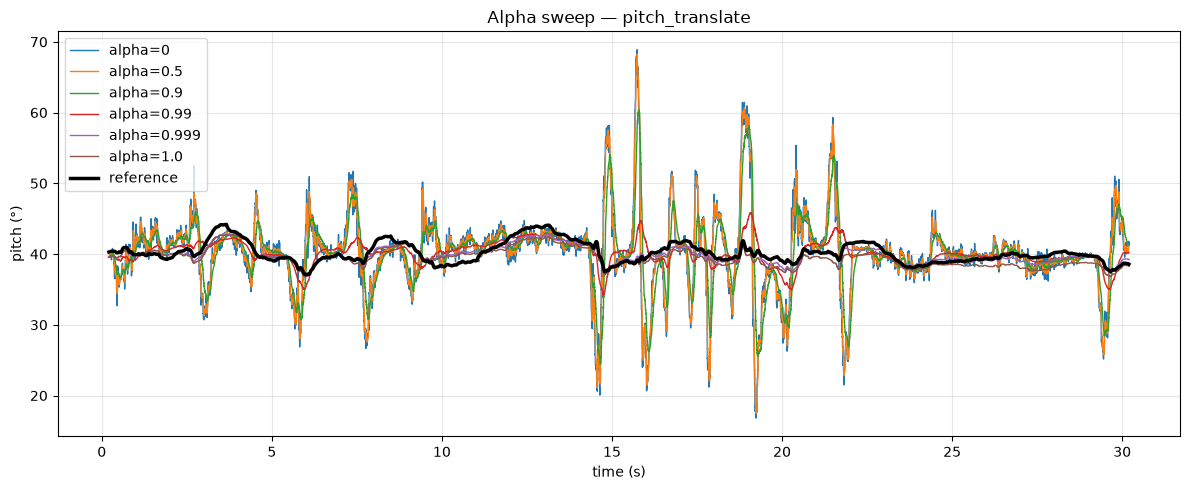

In [47]:
# Choose alphas
alphas = [0, 0.5, 0.9, 0.99, 0.999, 1.0]

# Choose initial pitch (comment this out to use accelerometer reading)
# pitch_init = 0

# Run a filter for each alpha value
traces = []
for alpha in alphas:
    ts, pitches = run_complementary_filter(events, alpha, pitch_init)
    traces.append((ts, pitches, f"alpha={alpha}"))

# Add the reference trace to the end
traces.append((t_quat, pitch_quat, "reference", {"color": "k", "lw": 2.5}))

# Plot our naive acceleration and gyroscope pitch estimations vs. the reference
plot_pitch(traces, title=f"Alpha sweep — {rec.path.name}")

## Sweep Alpha Over Hold

Now, let's see how the different alpha values compare on a pitch-then-hold motion.

In [54]:
# Load recording
rec = load("../recordings/pitch_static_hold")

# Sort acc and gyro streams into a single, sorted (by time) list
events = rec.sorted_streams("acc", "gyro")

# Get pitch from reference data
t_quat = rec.ref.t
quat = rec.ref.quat()
pitch_quat = pitch_from_quat(quat)

# Find initial pitch based on first accelerometer reading
for event in events:
    t, name, vals = event
    if name == "acc":
        ax = vals[0]
        az = vals[2]
        pitch_init = math.degrees(math.atan2(-ax, az))
        break
print(f"Initial pitch: {pitch_init:.2f} deg")

Initial pitch: -1.59 deg


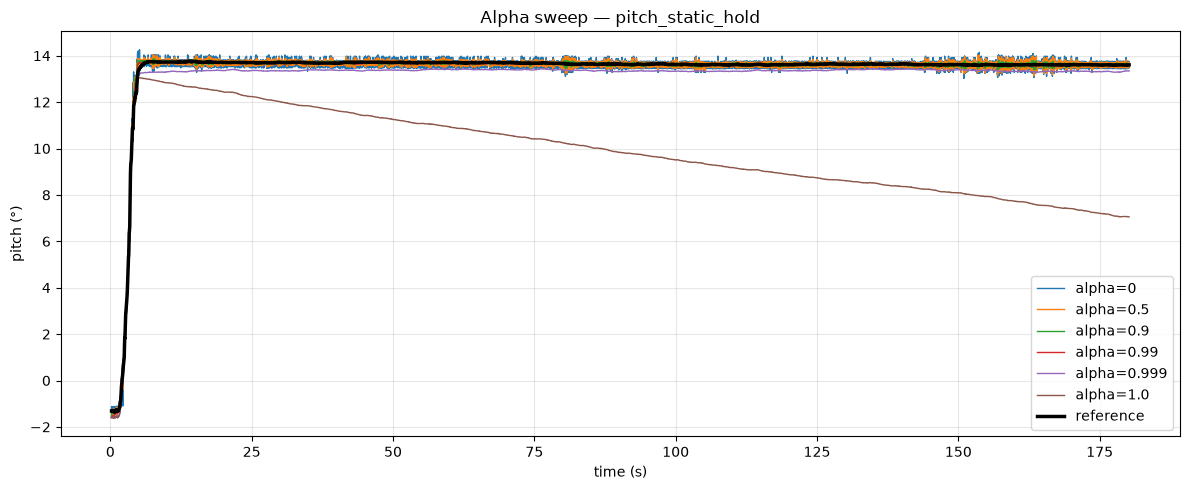

In [55]:
# Choose alphas
alphas = [0, 0.5, 0.9, 0.99, 0.999, 1.0]

# Choose initial pitch (comment this out to use accelerometer reading)
# pitch_init = 0

# Run a filter for each alpha value
traces = []
for alpha in alphas:
    ts, pitches = run_complementary_filter(events, alpha, pitch_init)
    traces.append((ts, pitches, f"alpha={alpha}"))

# Add the reference trace to the end
traces.append((t_quat, pitch_quat, "reference", {"color": "k", "lw": 2.5}))

# Plot our naive acceleration and gyroscope pitch estimations vs. the reference
plot_pitch(traces, title=f"Alpha sweep — {rec.path.name}")